What makes us wealthy or not?
Can we predict weather someone is wealthy based on their marriage status or occupation ?

In this Notebook we compare two classification methods, Logistic Regression and a Random Forest Classifier with very easy python to solve a simple binary classification problem that can be taught to anyone!
The Logistic regression algorithm is a simple and easy to understand concept for those who are just starting with machine learning and Data Science.

In [1]:
# We Import only a few simple libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [35]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
# I set parameters early for graphing to make a consistent format
plt.rcParams.update({'font.size':18})
plt.rcParams['figure.figsize'] = [40,10]

The code comes from Kaggle.com https://www.kaggle.com/wenruliu/adult-income-dataset
It is a large DataFrame of different attributes of individuals and weather or not they make more than 50K USD.

In [3]:
df = pd.read_csv(r"E:\Springboard\adult.csv")
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [5]:
df.isnull().sum().sort_values(ascending=False).head(15)

age                0
workclass          0
fnlwgt             0
education          0
educational-num    0
marital-status     0
occupation         0
relationship       0
race               0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
income             0
dtype: int64

In [6]:
df.describe()

,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [7]:
print('Shape of DF')
print(df.shape)
df[df['workclass'].str.find('?')==0].head(10)
print('Shape of Unknown Workclass and Occupation')
df[df['workclass'].str.find('?')==0].shape
2799/48842

Shape of DF
(48842, 15)
Shape of Unknown Workclass and Occupation


0.05730723557593874

We are missing values for Workclass and occupation for 5% of the samples.
We may not need this information but its good to know where the missing info is located.
I will drop these samples.

In [8]:
print(df.shape)
df[df['workclass'].str.find('?')==0]
df.shape

(48842, 15)


(48842, 15)

In [9]:
# I replace the '?' with NaN and drop the nan
df = df.replace('?',np.nan)
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


In [10]:
#THe full shape
df = df.dropna()
df.shape

(45222, 15)

I Want to explore the variables in the dataframe

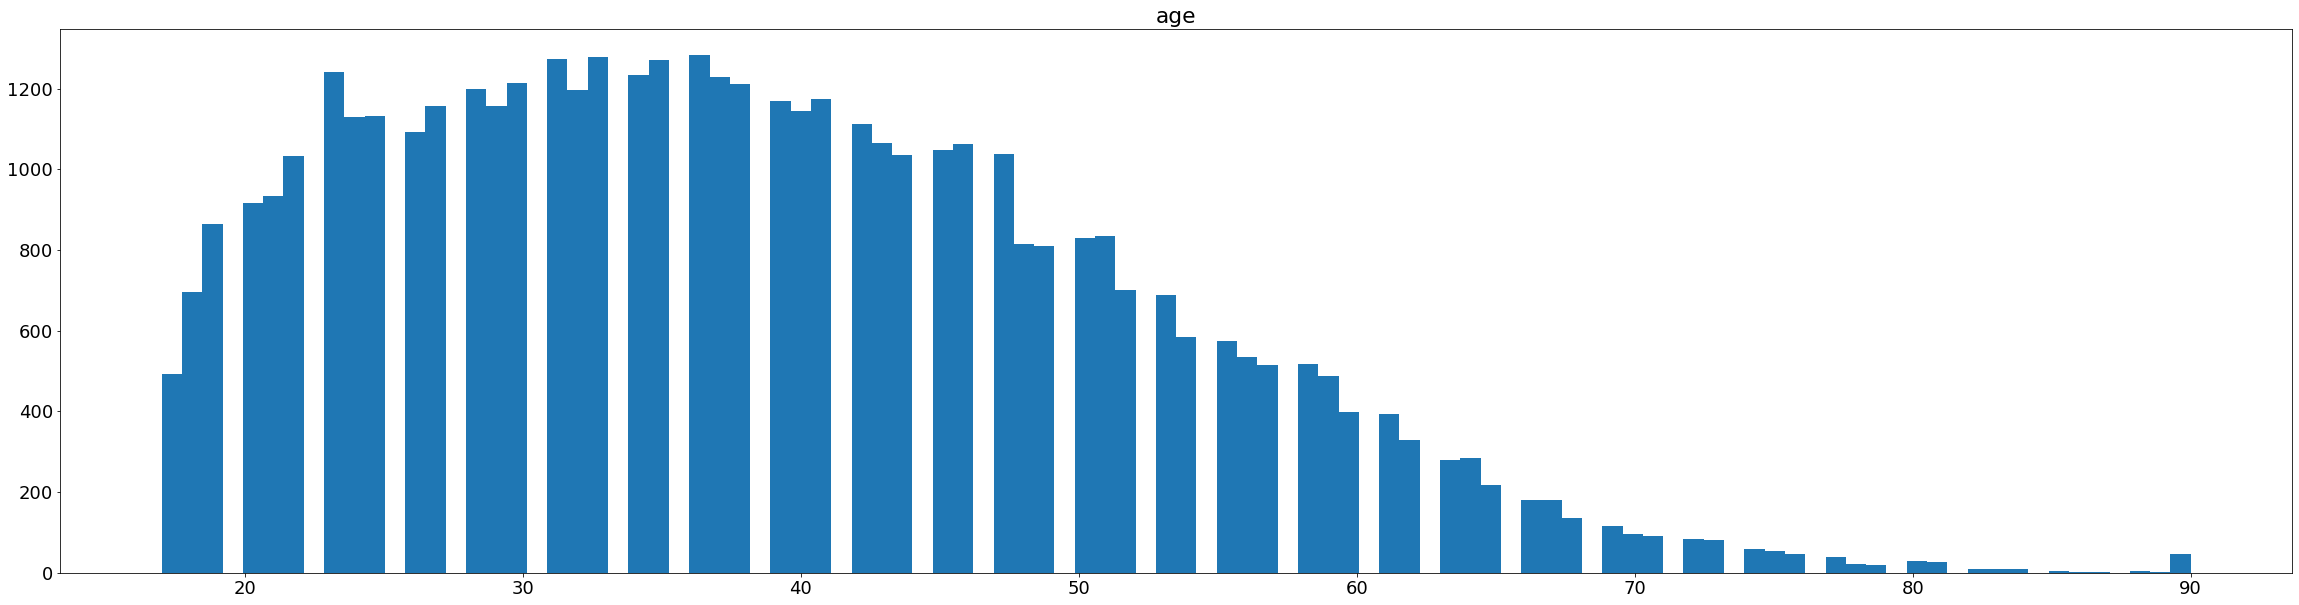

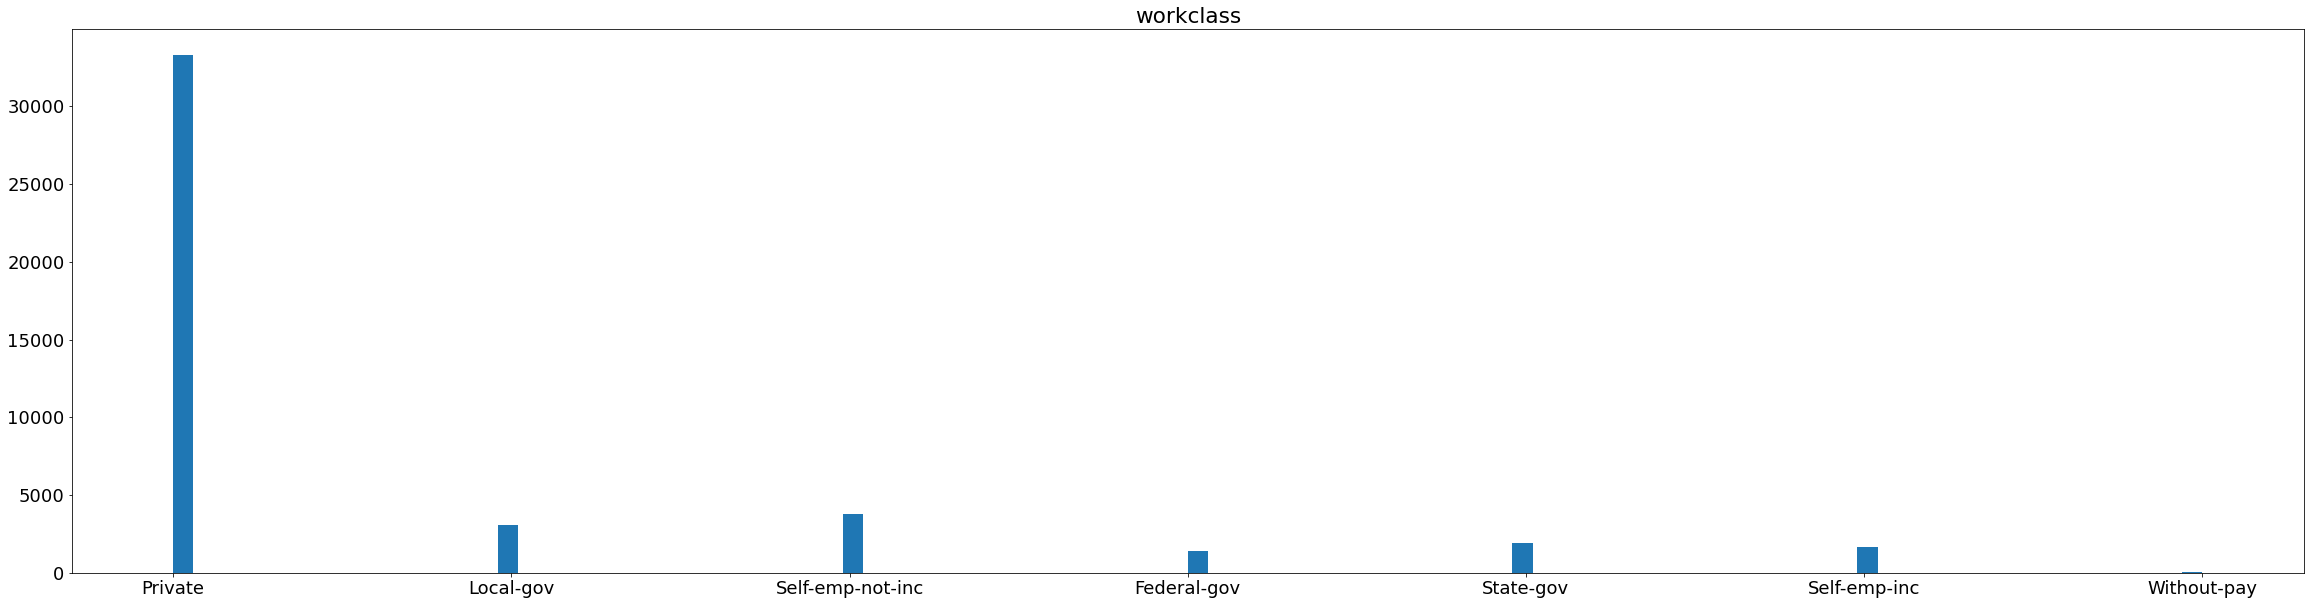

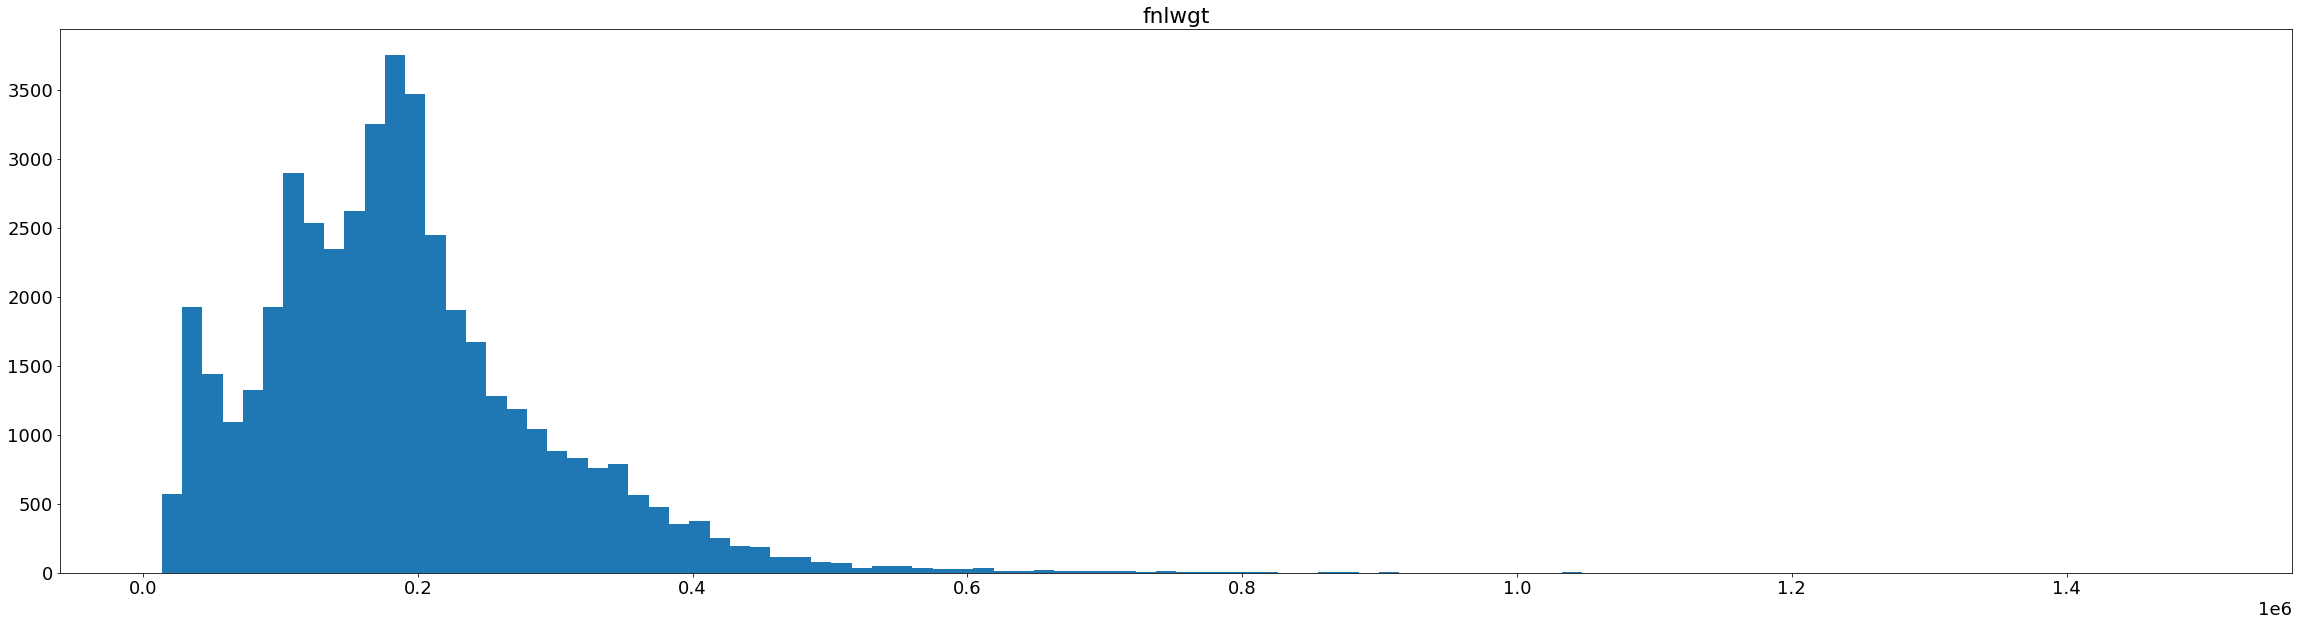

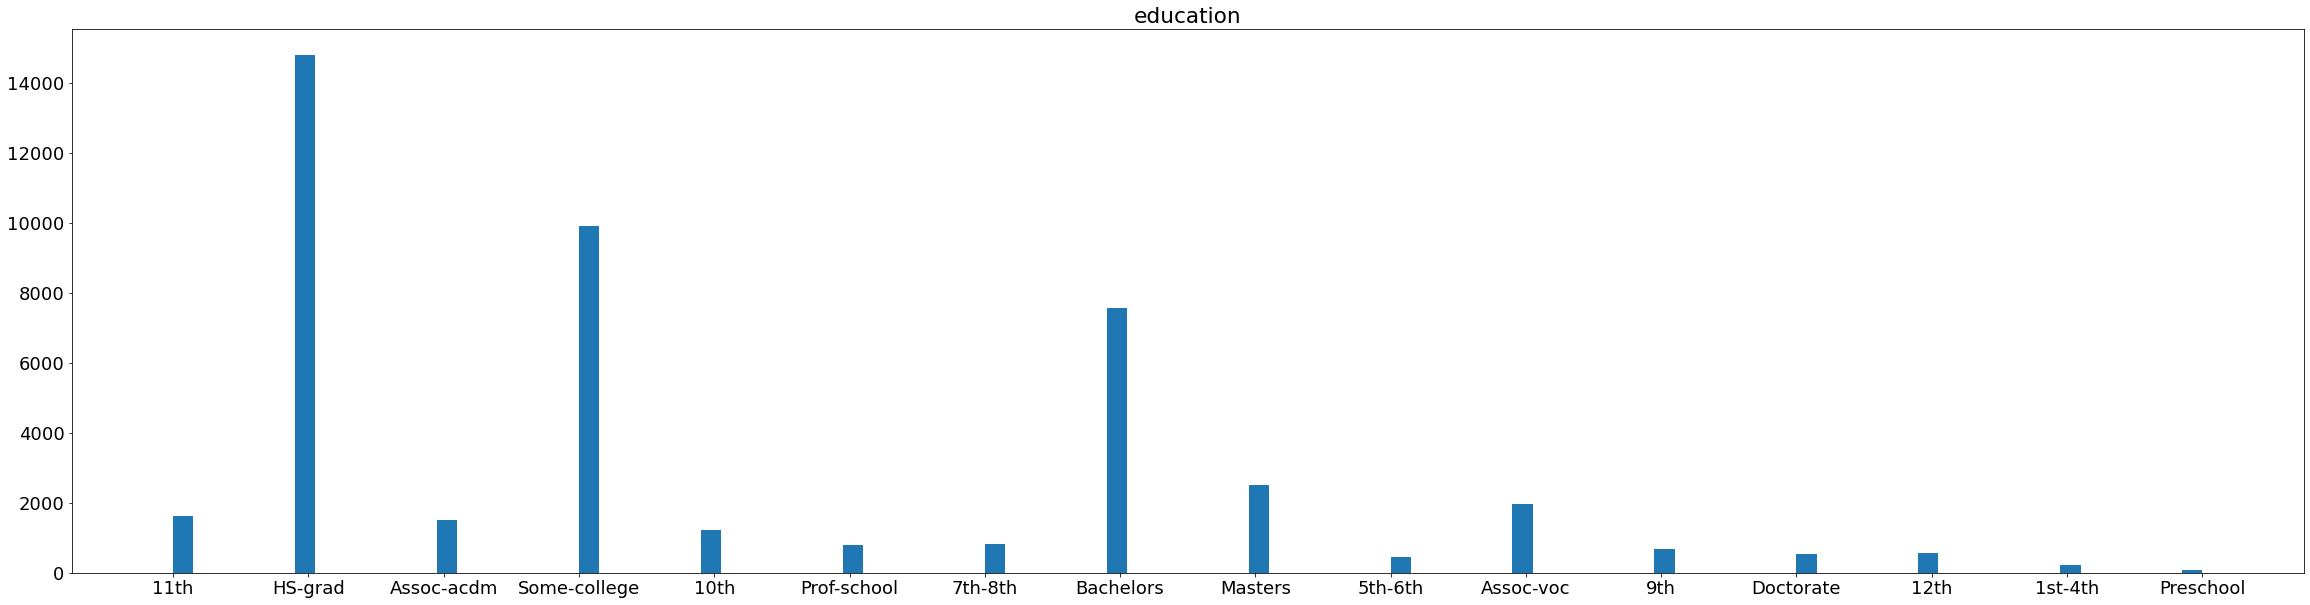

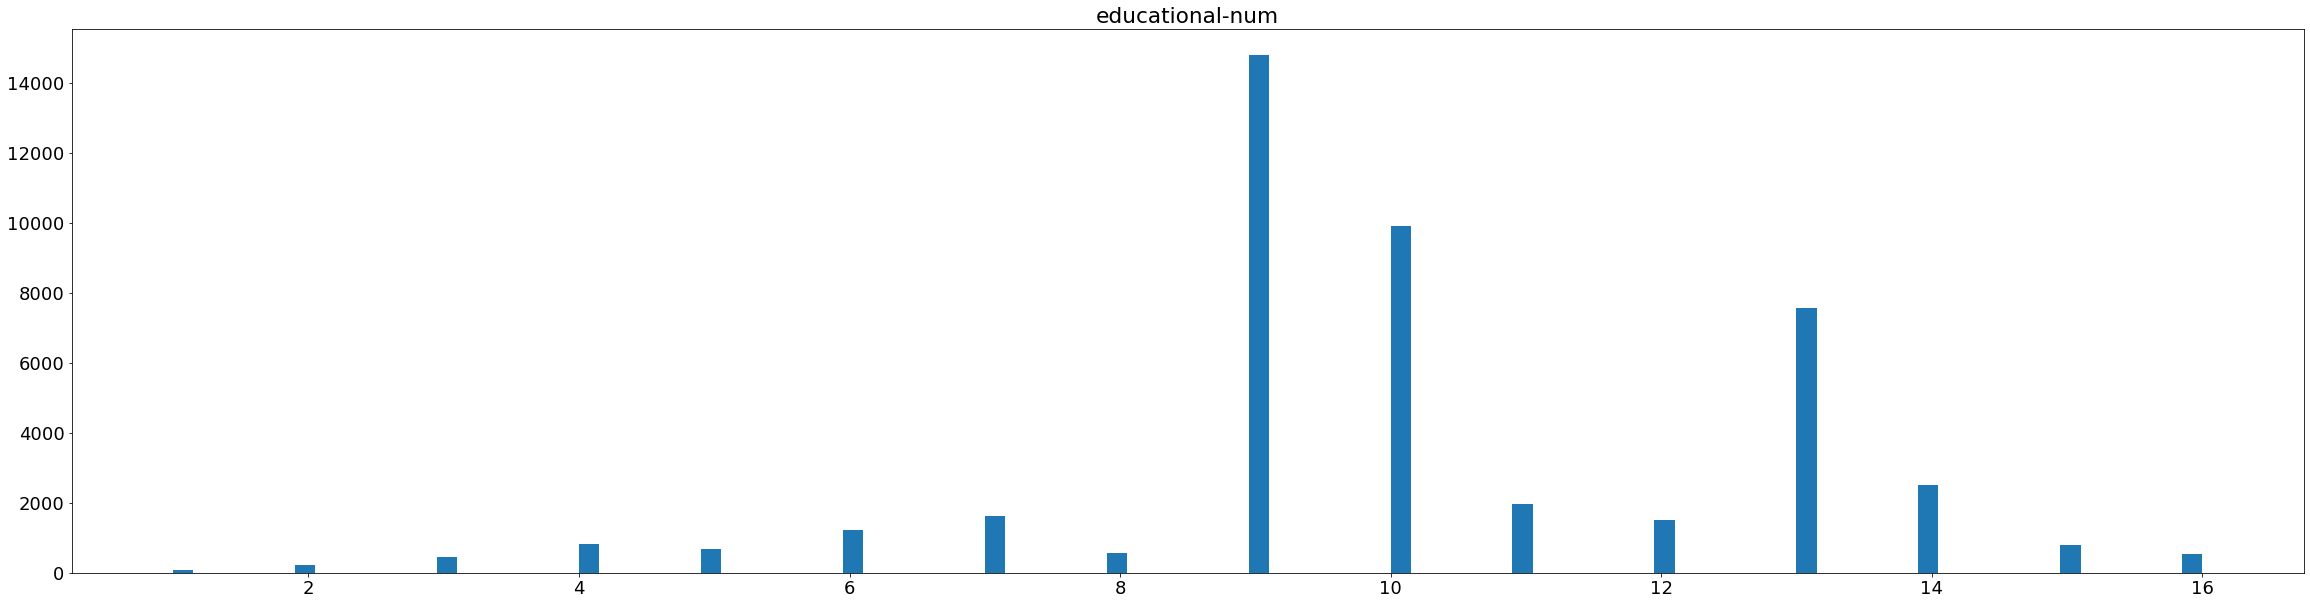

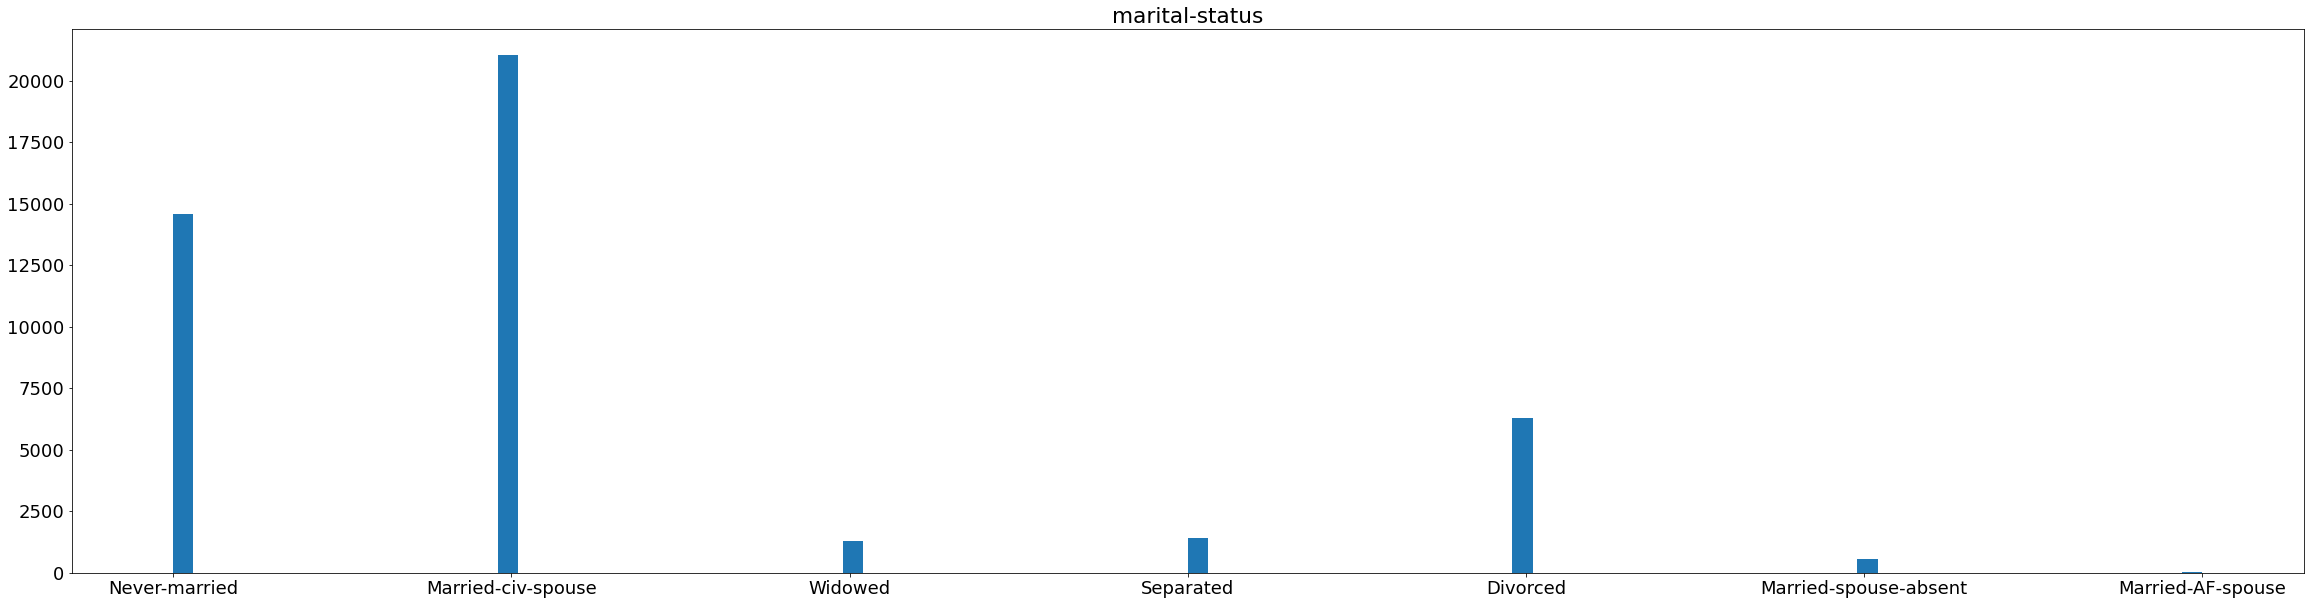

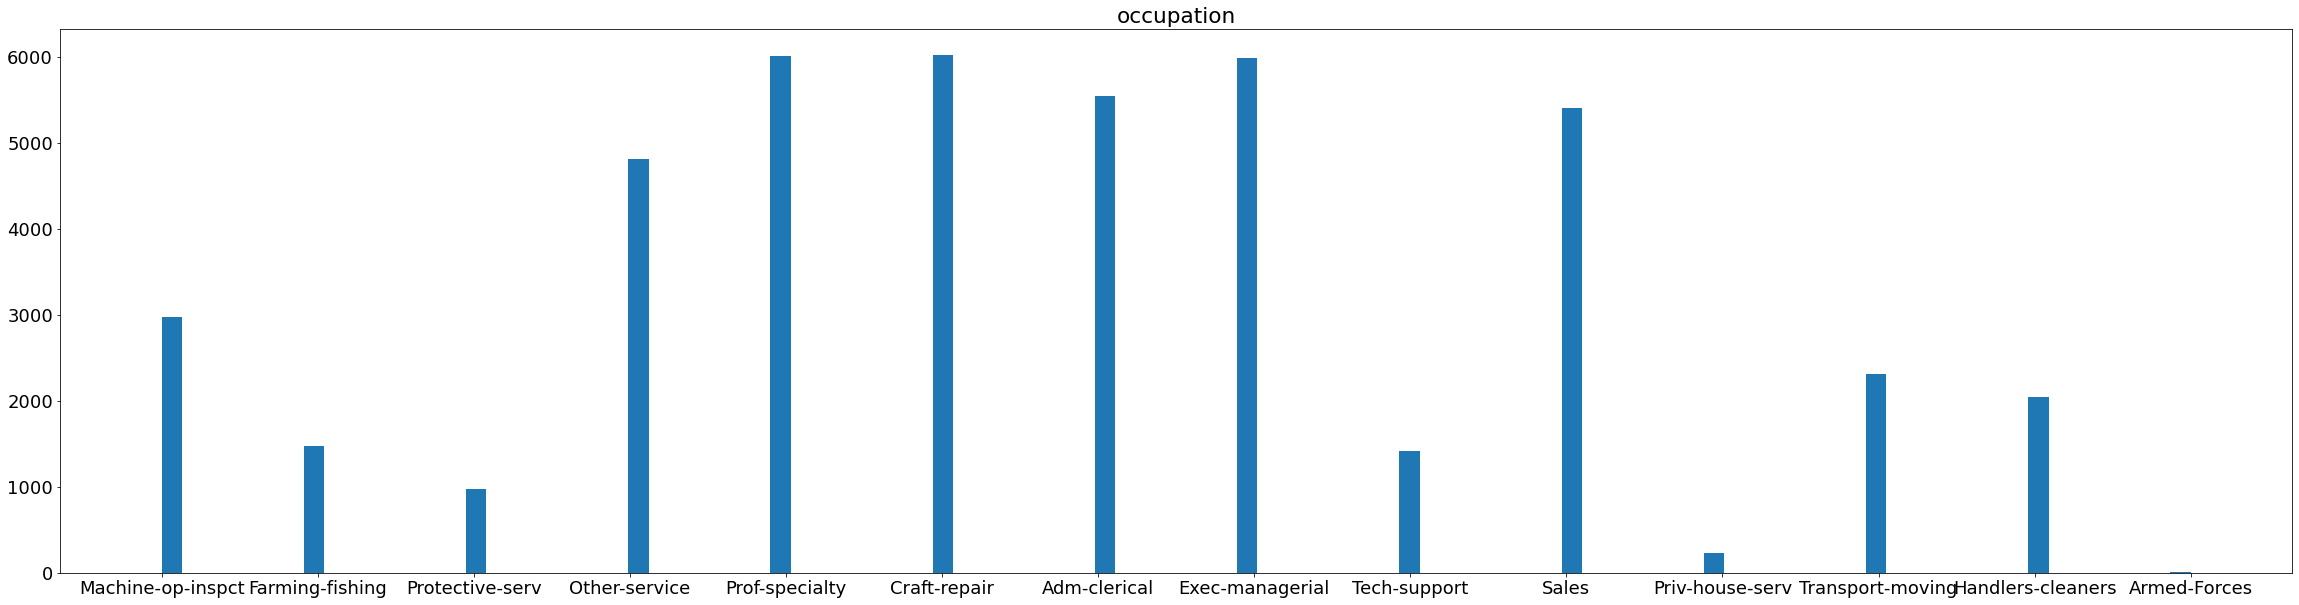

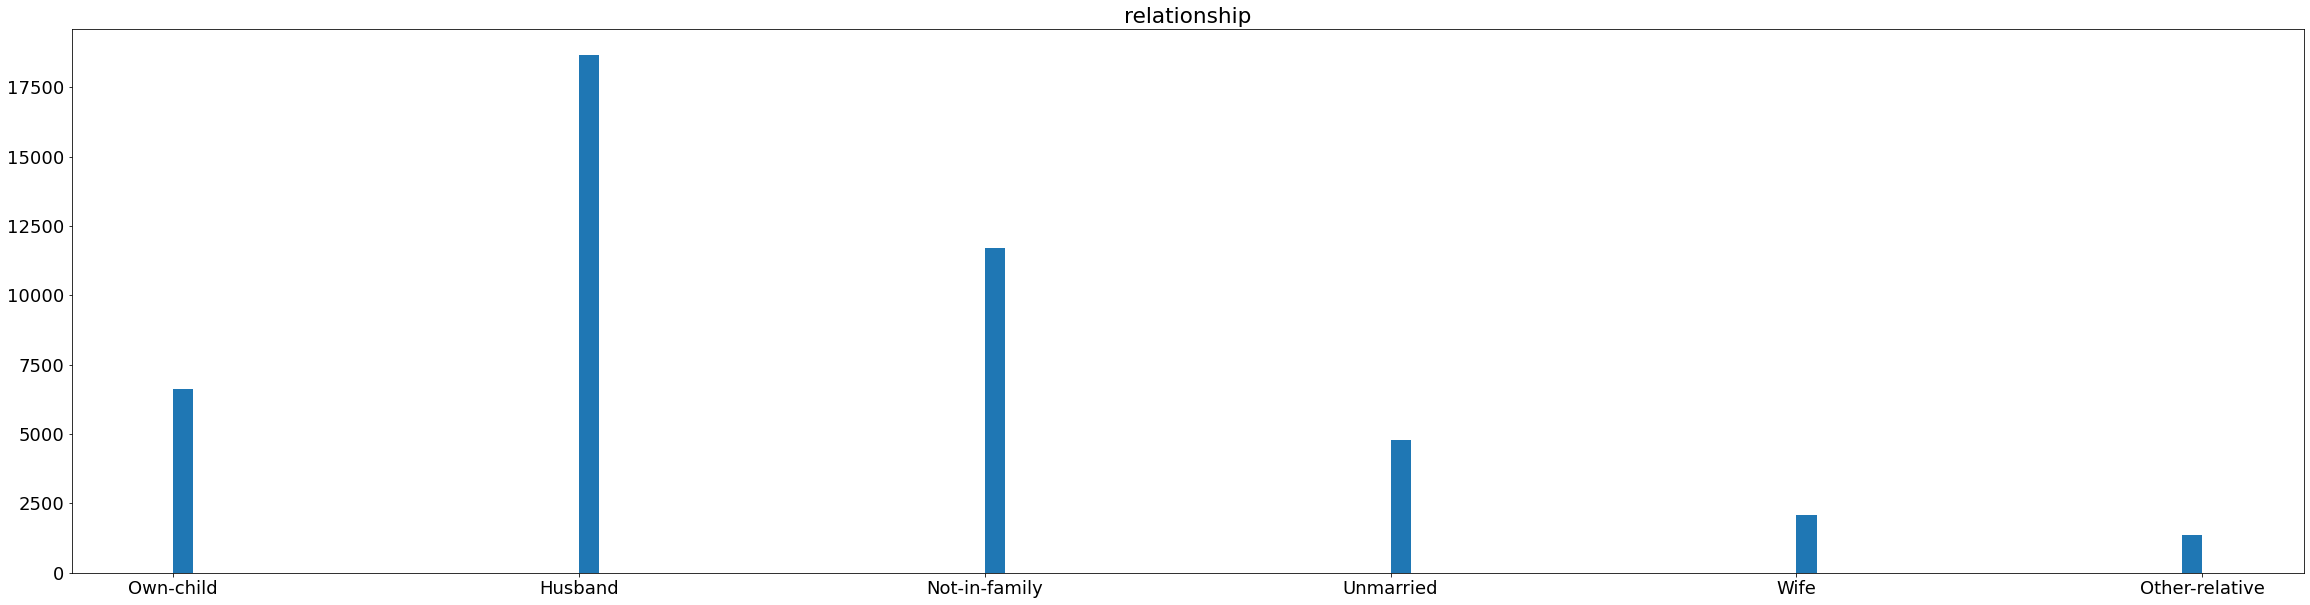

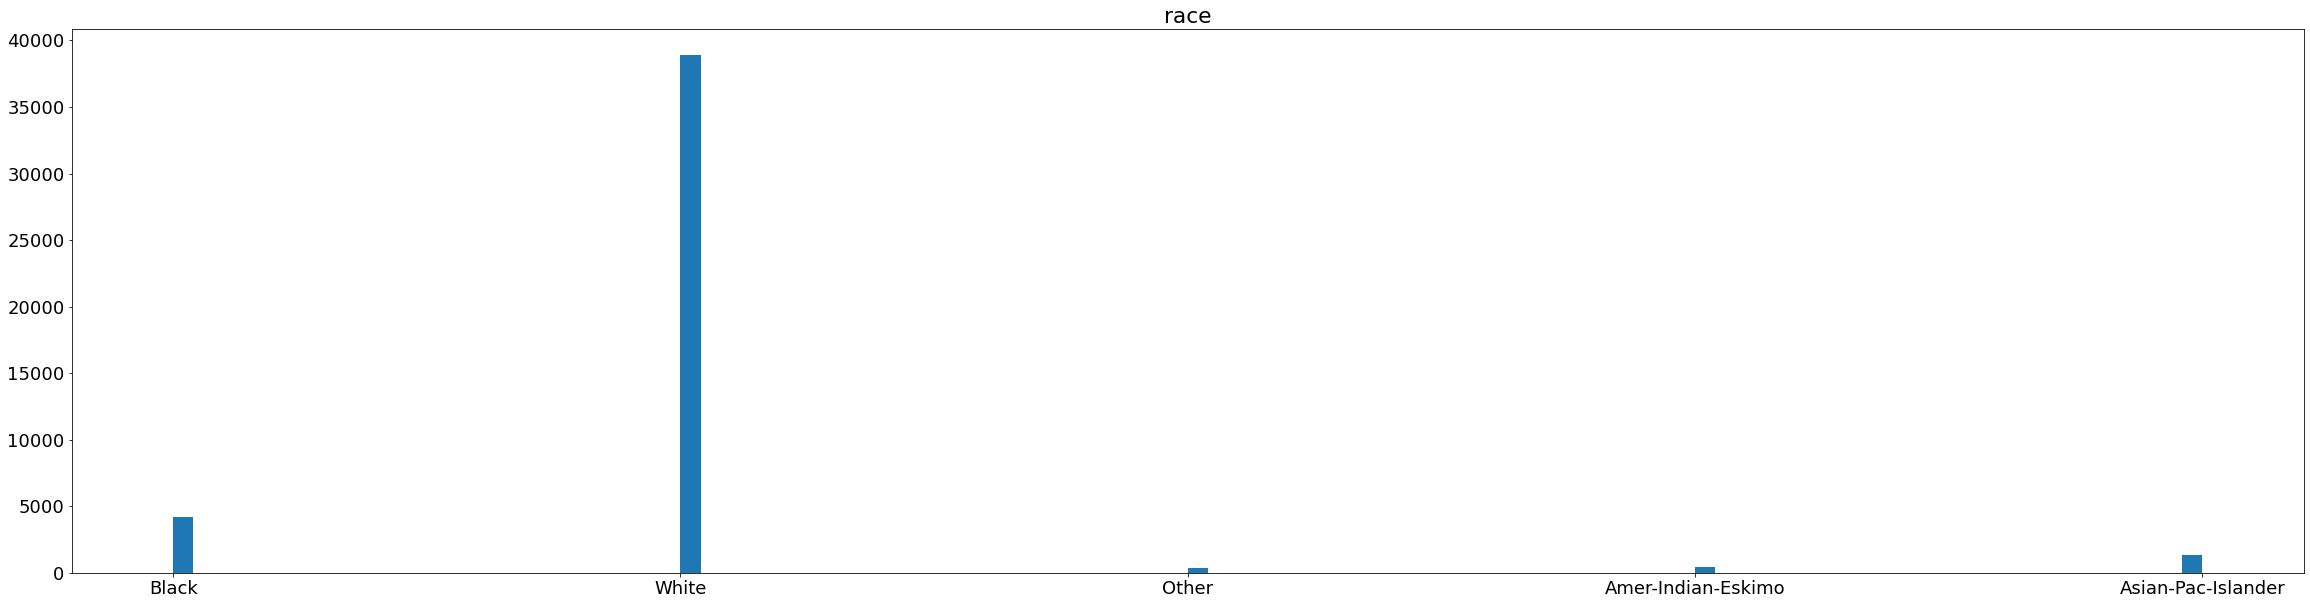

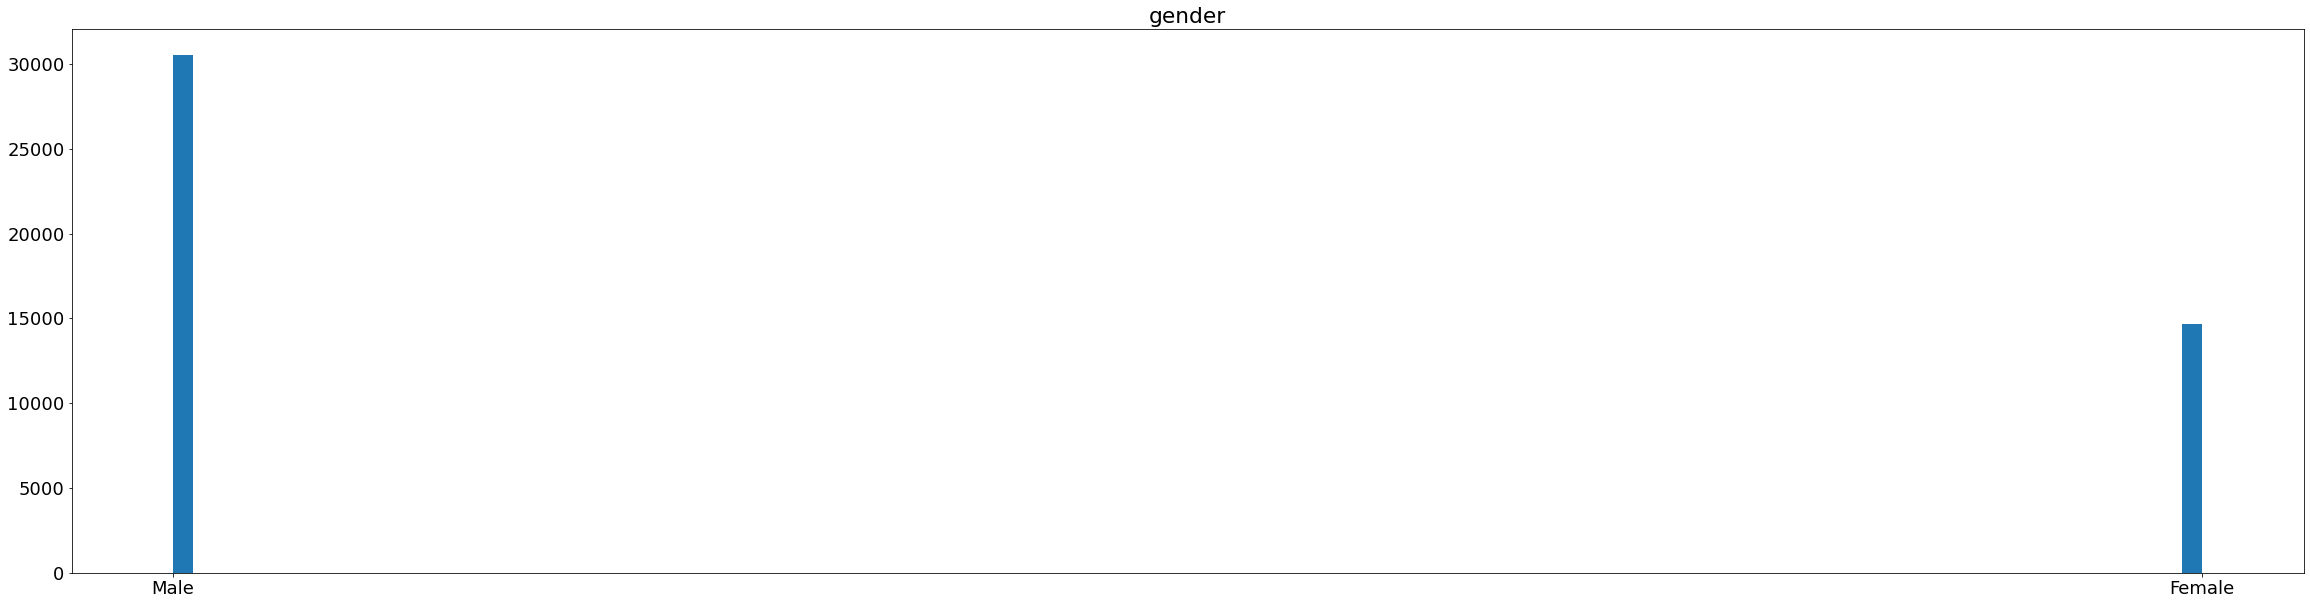

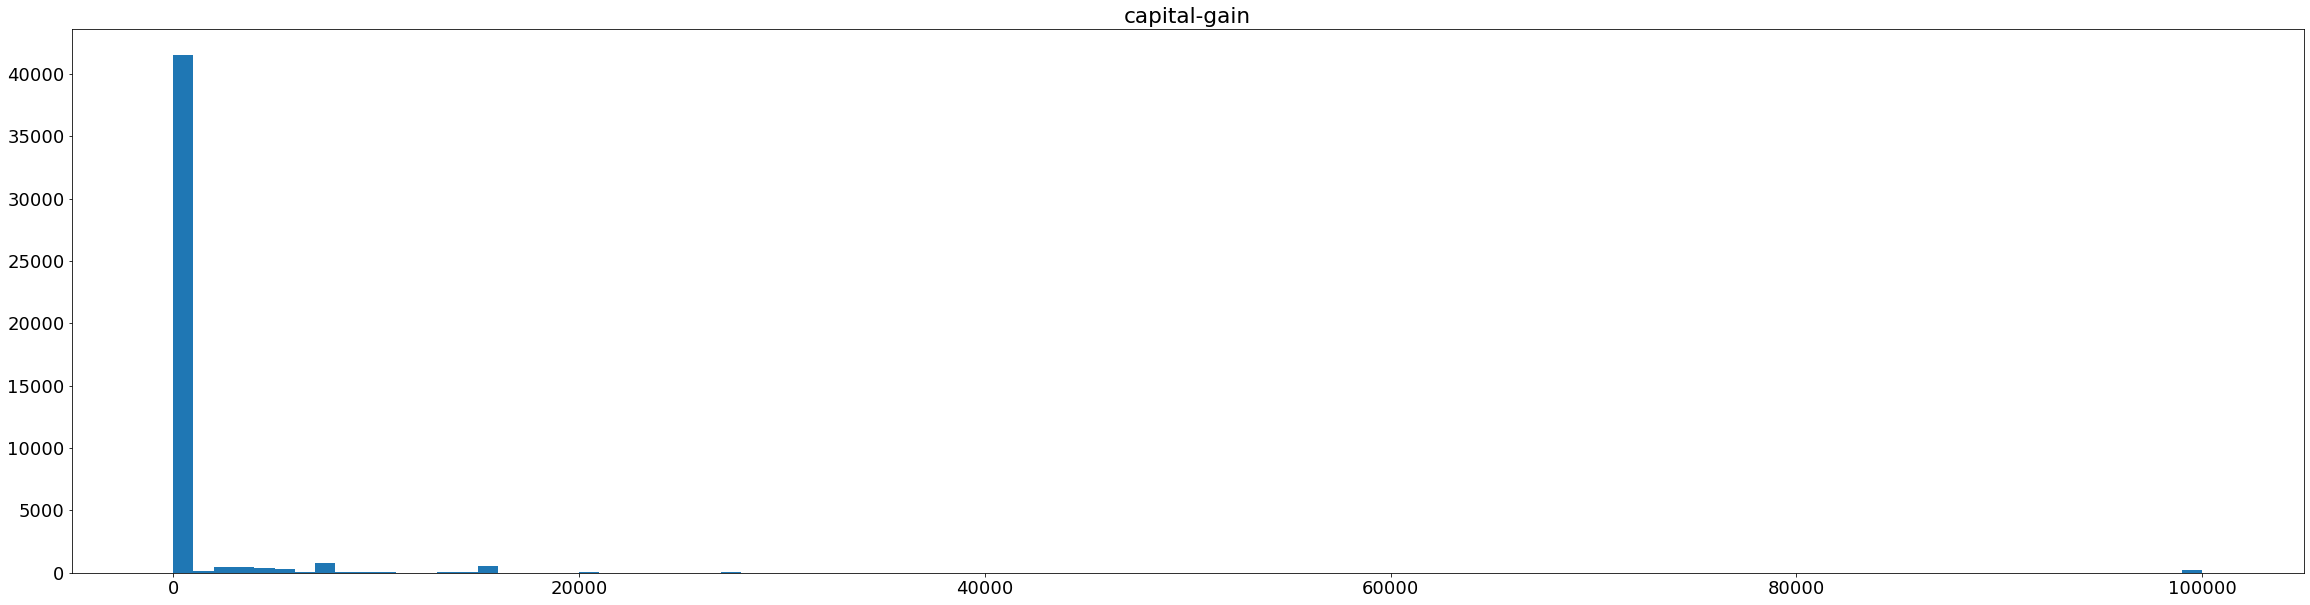

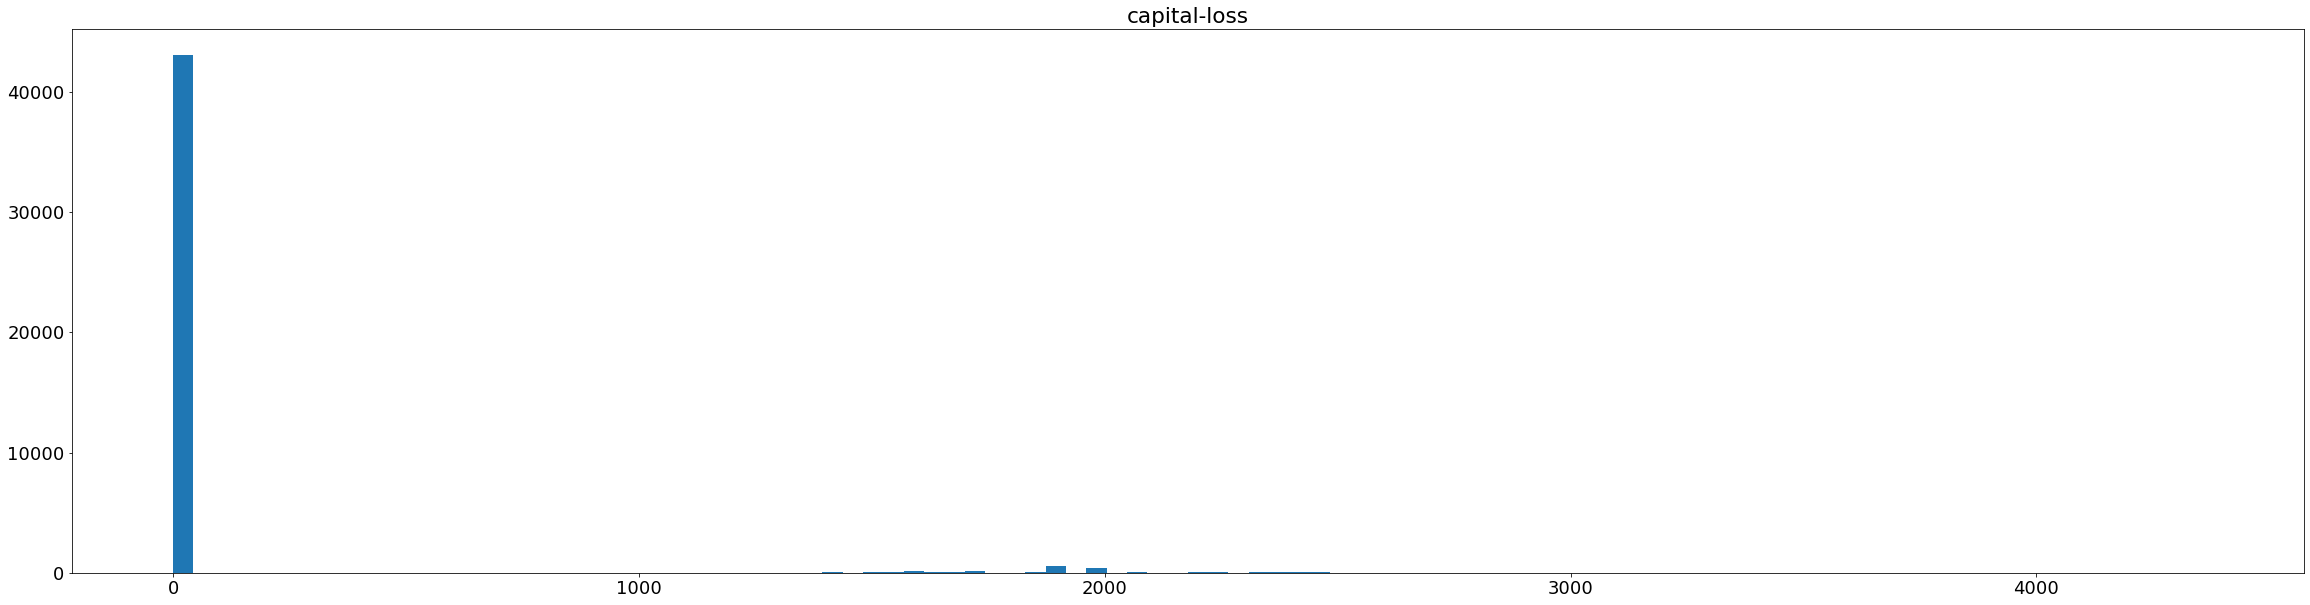

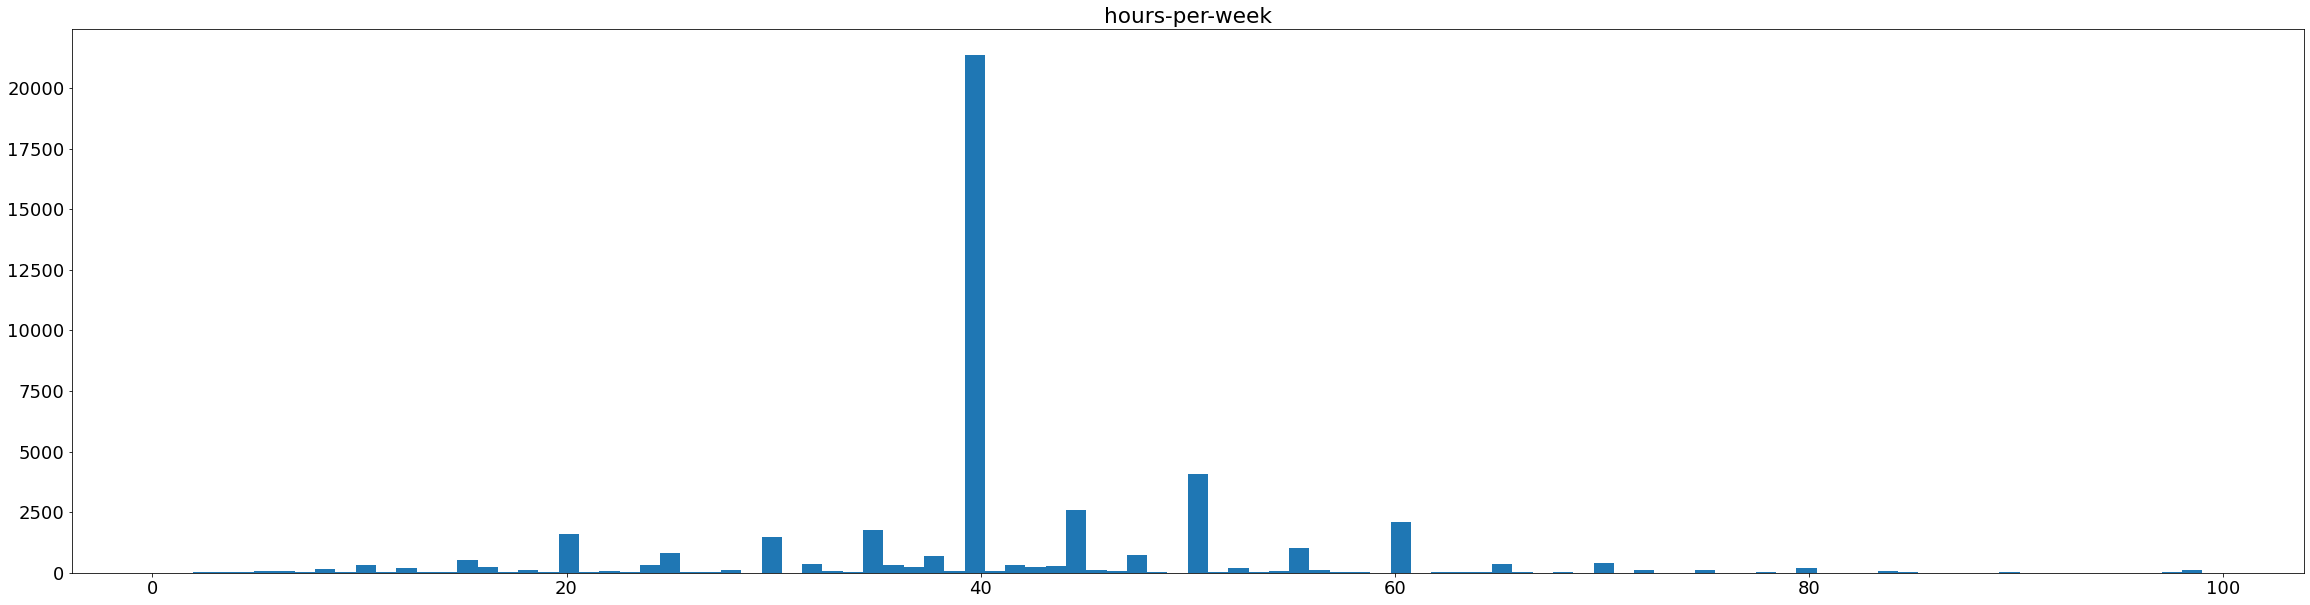

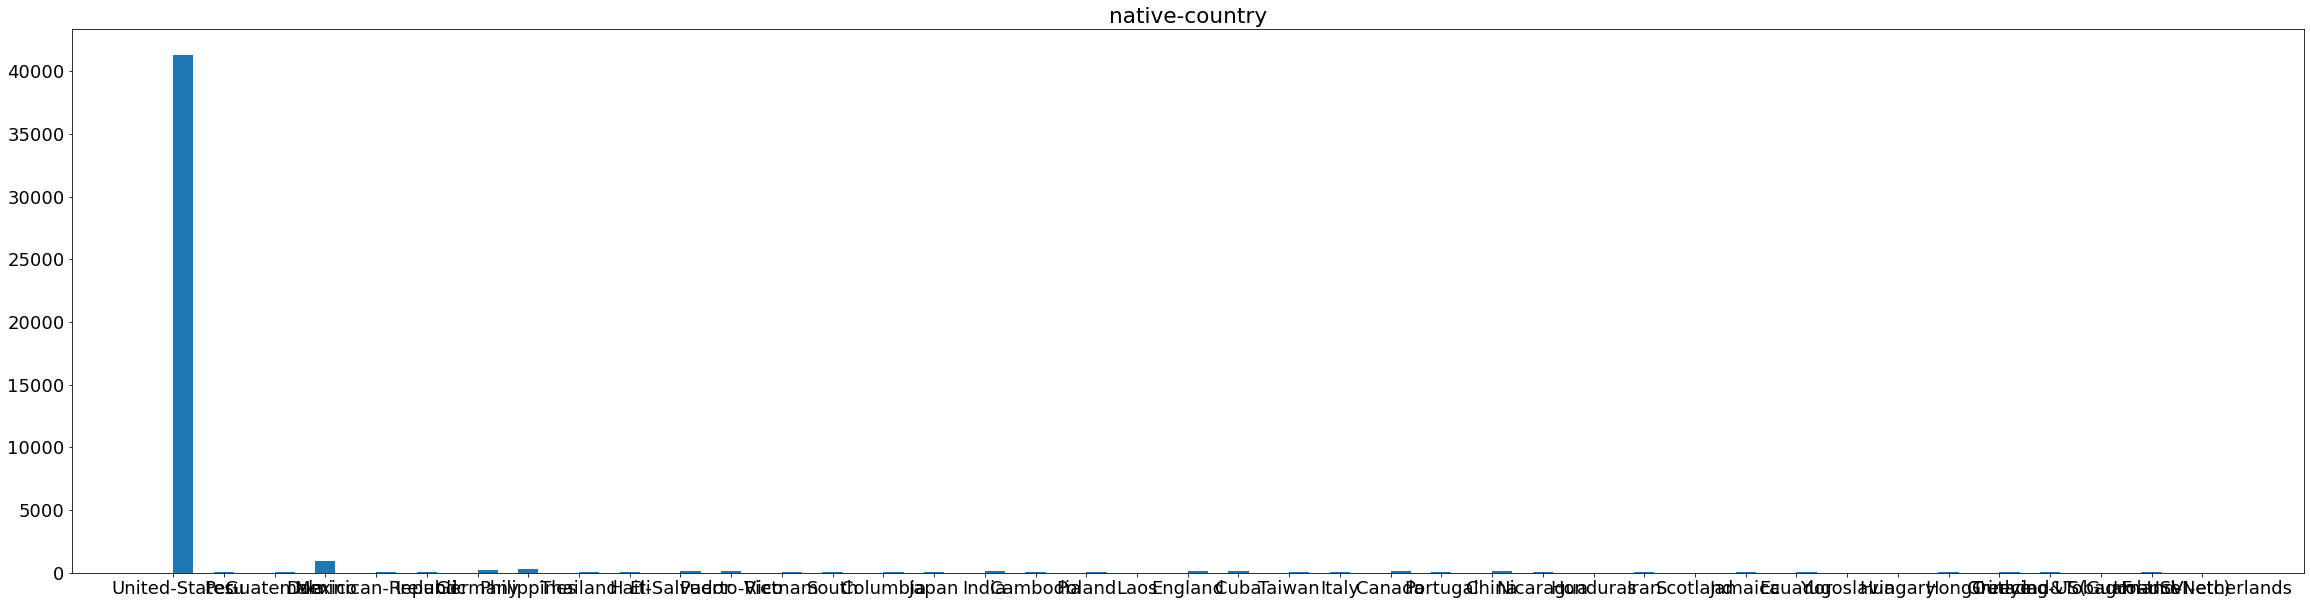

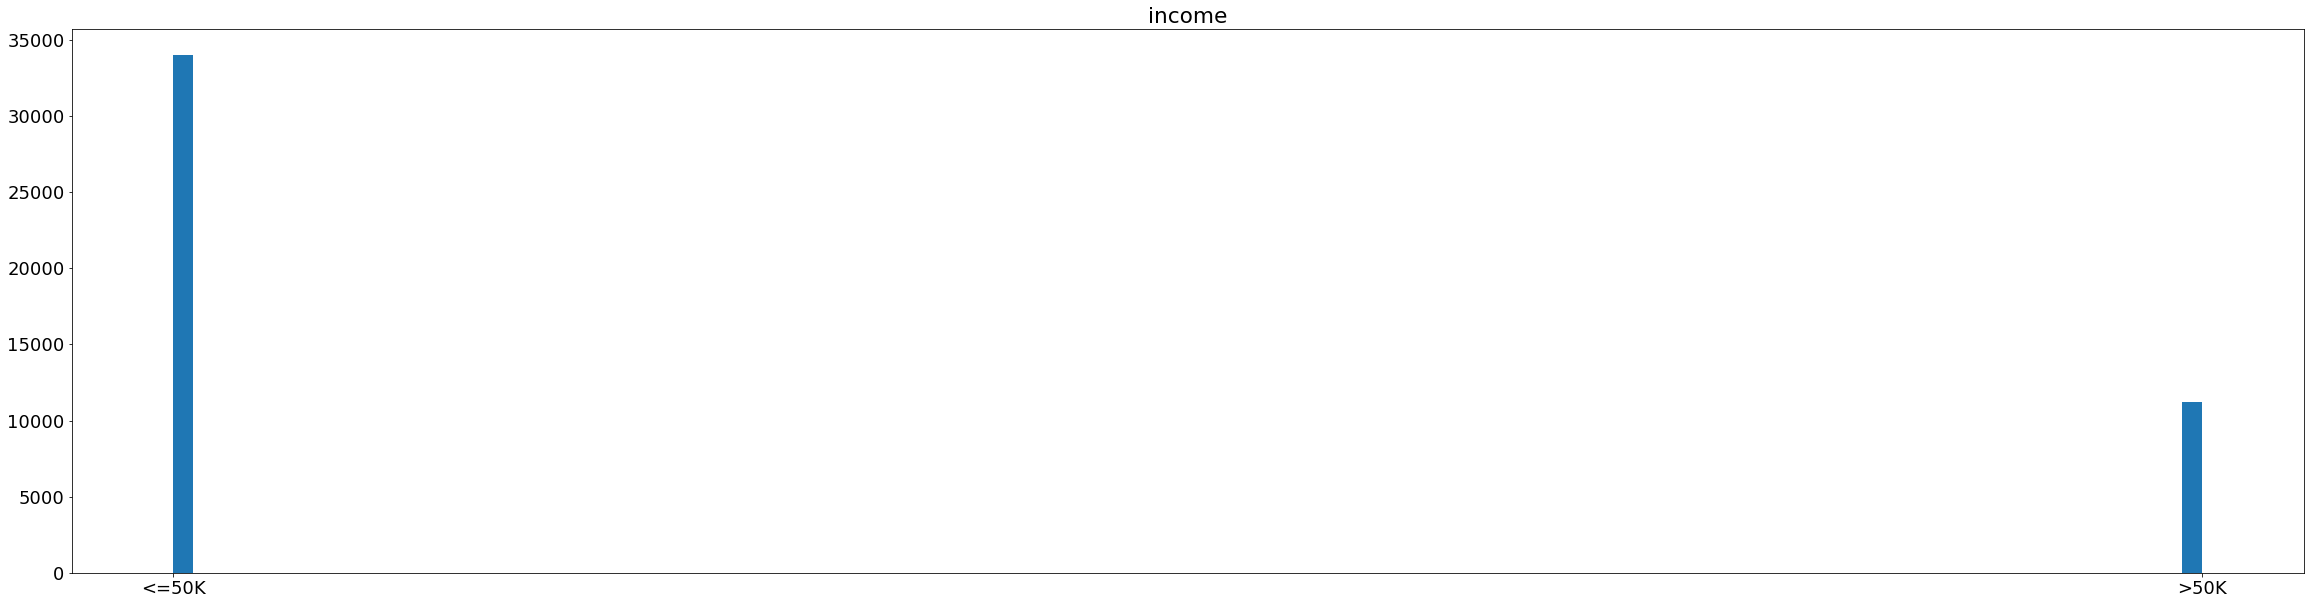

In [11]:
for i in df.columns:
    plt.hist(df[i],bins=100)
    plt.title(str(i))
    plt.show()

The histograms reveal some great information about our Data. For example we can see that most subjects work in a private company,We can see most persons work 40 hours a week and most subjects have 0 capital gains and losses.
So many interesting insights allready, Pandas is an excellent library for all tabular datasets. It makes wrangling data so fast and easy you'll forget what a vlookup even means !

In [12]:
# Here we take the average of each numerical variable and print for all those making less than 50K
df[df['income']=='<=50K'].mean()

age                    36.749427
fnlwgt             190175.214235
educational-num         9.630770
capital-gain          149.023402
capital-loss           54.032428
hours-per-week         39.372023
dtype: float64

In [13]:
# And Now greater than 50K
df[df['income']=='>50K'].mean()

age                    44.006067
fnlwgt             188397.967345
educational-num        11.598501
capital-gain         3991.791667
capital-loss          193.487063
hours-per-week         45.690489
dtype: float64

I wonder if we can visualize how the numeric variables are correlated with one another.
A heatmap is a great way to view the correlations of each numeric variable, its fast and easy.

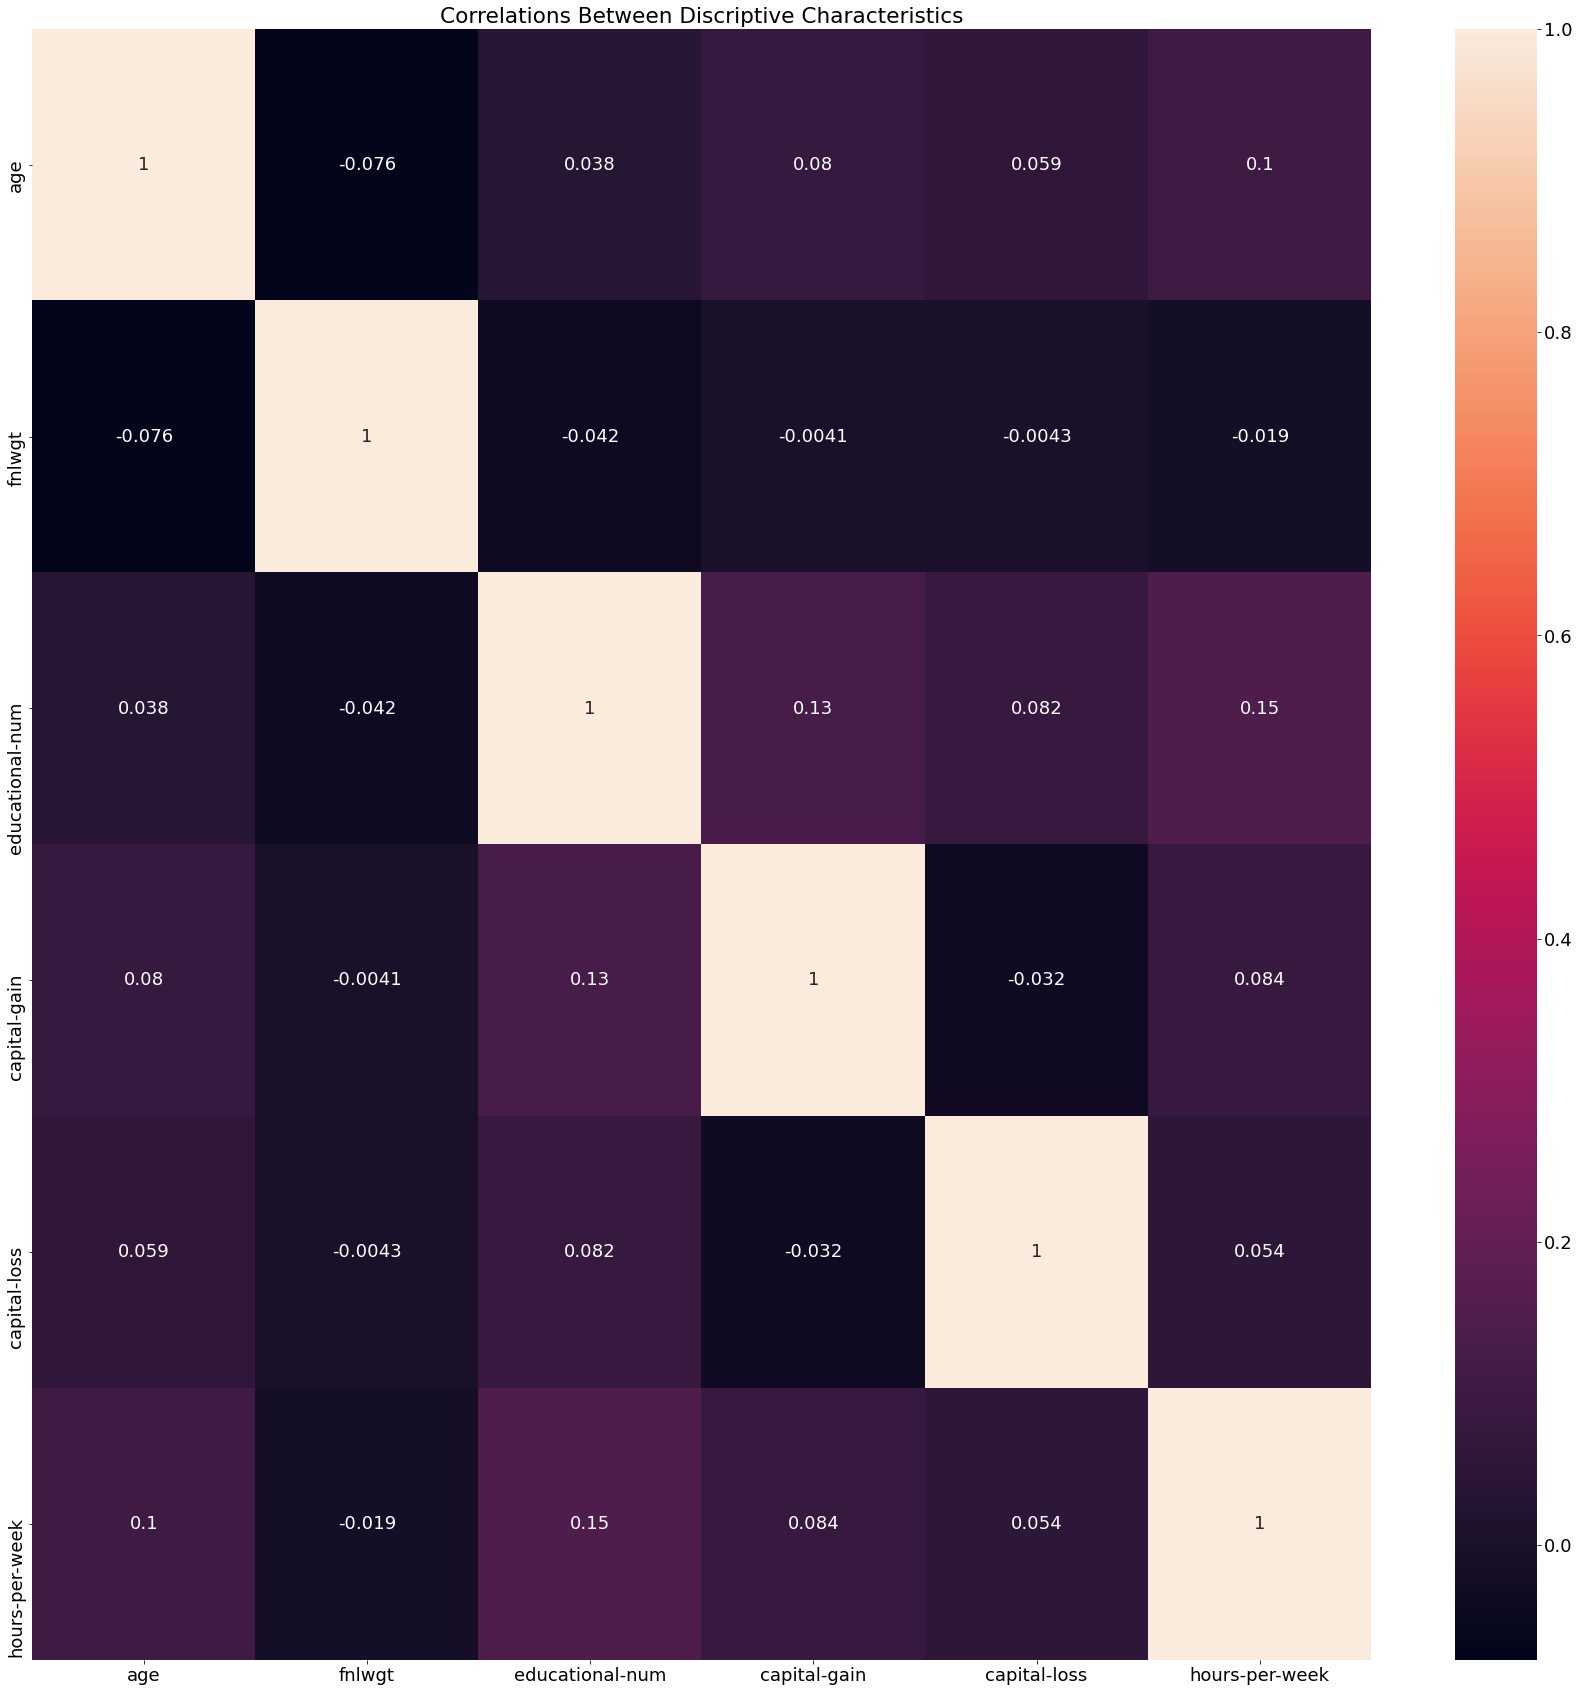

In [14]:
plt.figure(figsize=(30,30))
plt.title('Correlations Between Discriptive Characteristics')
sns.heatmap(df.corr(),annot=True)
plt.show()

The heatmap tells us how each of the variables are correlated to each other, however none of the relationships are really that strong so its hard to gain any real insights about our data.
We also are not able to correlate this data with our binary question weather or not someone makes more than 50K a year.

Lets dig a bit deeper to see what other low hanging fruit we can explore.

In [15]:
print('Highest Earners')
df[df['hours-per-week'] == 99].sort_values('income',ascending=False).head()

Highest Earners


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
384,29,Private,211208,11th,7,Married-civ-spouse,Transport-moving,Husband,White,Male,0,0,99,United-States,>50K
42877,35,Private,297574,Assoc-acdm,12,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,99,United-States,>50K
42112,31,Private,147284,Doctorate,16,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,1977,99,United-States,>50K
41994,32,Private,183304,Assoc-voc,11,Married-civ-spouse,Transport-moving,Husband,White,Male,0,0,99,United-States,>50K
901,37,Private,112158,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,7688,0,99,United-States,>50K


In [16]:
print('Lowest Earners')
df[df['hours-per-week'] == 99].sort_values('income').head()

Lowest Earners


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
26547,56,Self-emp-inc,184598,9th,5,Married-civ-spouse,Transport-moving,Husband,White,Male,0,0,99,United-States,<=50K
34884,33,Self-emp-not-inc,67482,Assoc-voc,11,Divorced,Other-service,Unmarried,White,Female,0,0,99,United-States,<=50K
33892,28,Self-emp-not-inc,104617,7th-8th,4,Never-married,Other-service,Other-relative,White,Female,0,0,99,Mexico,<=50K
33273,19,Private,121074,7th-8th,4,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,99,United-States,<=50K
33149,53,Private,178356,Assoc-acdm,12,Married-civ-spouse,Exec-managerial,Husband,White,Male,2407,0,99,United-States,<=50K


INSIGHT
All the above are working 99 hours a weeks or more yet the second table shows 5 persons making less than 50K a year, meaning that hours worked is not well correlated with income earned.

How do different occupations impact income?
What are the highest paid proffessions ?

In [17]:
occupation_list = df['occupation'].unique()
occupation_list

array(['Machine-op-inspct', 'Farming-fishing', 'Protective-serv',
       'Other-service', 'Prof-specialty', 'Craft-repair', 'Adm-clerical',
       'Exec-managerial', 'Tech-support', 'Sales', 'Priv-house-serv',
       'Transport-moving', 'Handlers-cleaners', 'Armed-Forces'],
      dtype=object)

Are some occupations more likely to make you wealthy?
That would be something Id love to know. 

Lets look at the ratio of wealthy and not for each occuption.

In [18]:
for i in occupation_list:
    print(i)
    r = df[df['occupation'] == i]['income'].value_counts()
    print(r)
    print('Ratio')
    print(r[1]/r[0])

Machine-op-inspct
<=50K    2605
>50K      365
Name: income, dtype: int64
Ratio
0.1401151631477927
Farming-fishing
<=50K    1308
>50K      172
Name: income, dtype: int64
Ratio
0.13149847094801223
Protective-serv
<=50K    669
>50K     307
Name: income, dtype: int64
Ratio
0.4588938714499253
Other-service
<=50K    4612
>50K      196
Name: income, dtype: int64
Ratio
0.042497831743278404
Prof-specialty
<=50K    3304
>50K     2704
Name: income, dtype: int64
Ratio
0.8184019370460048
Craft-repair
<=50K    4665
>50K     1355
Name: income, dtype: int64
Ratio
0.2904608788853162
Adm-clerical
<=50K    4784
>50K      756
Name: income, dtype: int64
Ratio
0.15802675585284282
Exec-managerial
<=50K    3117
>50K     2867
Name: income, dtype: int64
Ratio
0.919794674366378
Tech-support
<=50K    1009
>50K      411
Name: income, dtype: int64
Ratio
0.40733399405351833
Sales
<=50K    3953
>50K     1455
Name: income, dtype: int64
Ratio
0.36807487983809767
Priv-house-serv
<=50K    229
>50K       3
Name: income, d

In [19]:
print('Average Capital Gain of High Earners')
print(df[df['income']=='>50K']['capital-gain'].mean())

print('Average Capital Loss of High Earners')
print(df[df['income']=='>50K']['capital-loss'].mean())

print('Win Loss Ratio of High Earners Capital Gains/Losses')
3991/194

Average Capital Gain of High Earners
3991.7916666666665
Average Capital Loss of High Earners
193.48706281227695
Win Loss Ratio of High Earners Capital Gains/Losses


20.572164948453608

In [20]:
print('Average Capital Gain of Low Earners')
df[df['income']=='<=50K']['capital-gain'].mean()

print('Average Capital Gain of Low Earners')
print(df[df['income']=='<=50K']['capital-loss'].mean())
print('Win Loss Ratio of Low Earners for Capital Gains/Losses')
150/54

Average Capital Gain of Low Earners
Average Capital Gain of Low Earners
54.032427823837246
Win Loss Ratio of Low Earners for Capital Gains/Losses


2.7777777777777777

Heres something to note, It would appear that high earners have better luck with the markets.
The Capital Gains of High Earners is 20 times their average losses however for Low income earners their capital gains are on average just twice their losses.

Although the boxplots are quite extended with outliers, I can see that an individual whose highest education was pre-school has one of the highest 

In [21]:
df.head()
he = df[df['income']=='>50K']
le = df[df['income']=='<=50K']
le

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
5,34,Private,198693,10th,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,<=50K
8,24,Private,369667,Some-college,10,Never-married,Other-service,Unmarried,White,Female,0,0,40,United-States,<=50K
9,55,Private,104996,7th-8th,4,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,10,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48834,32,Private,116138,Masters,14,Never-married,Tech-support,Not-in-family,Asian-Pac-Islander,Male,0,0,11,Taiwan,<=50K
48836,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
48837,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48839,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K


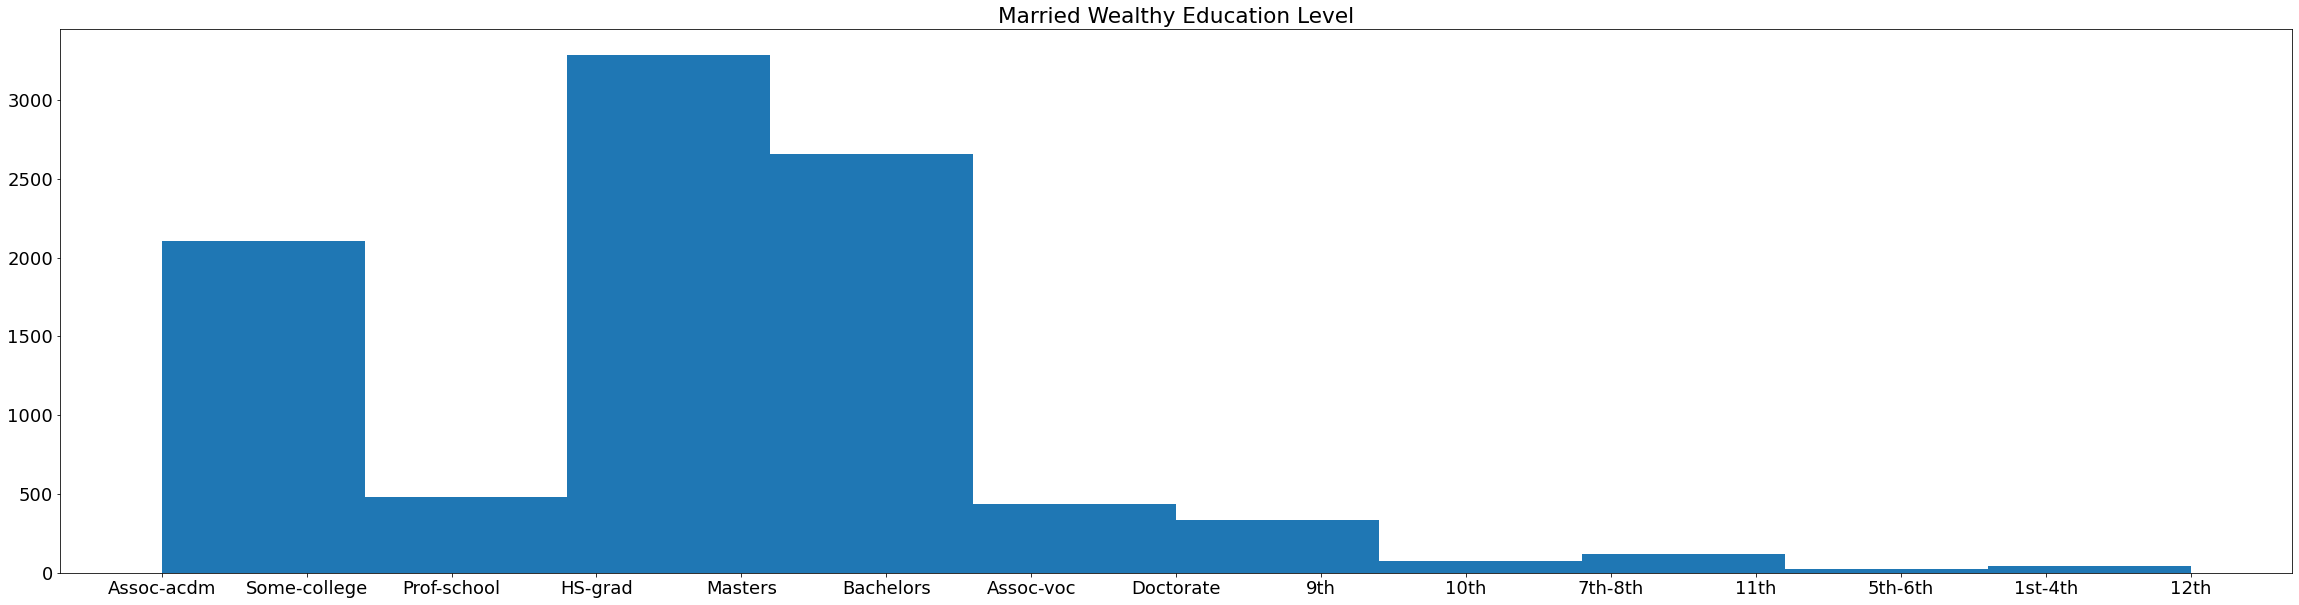

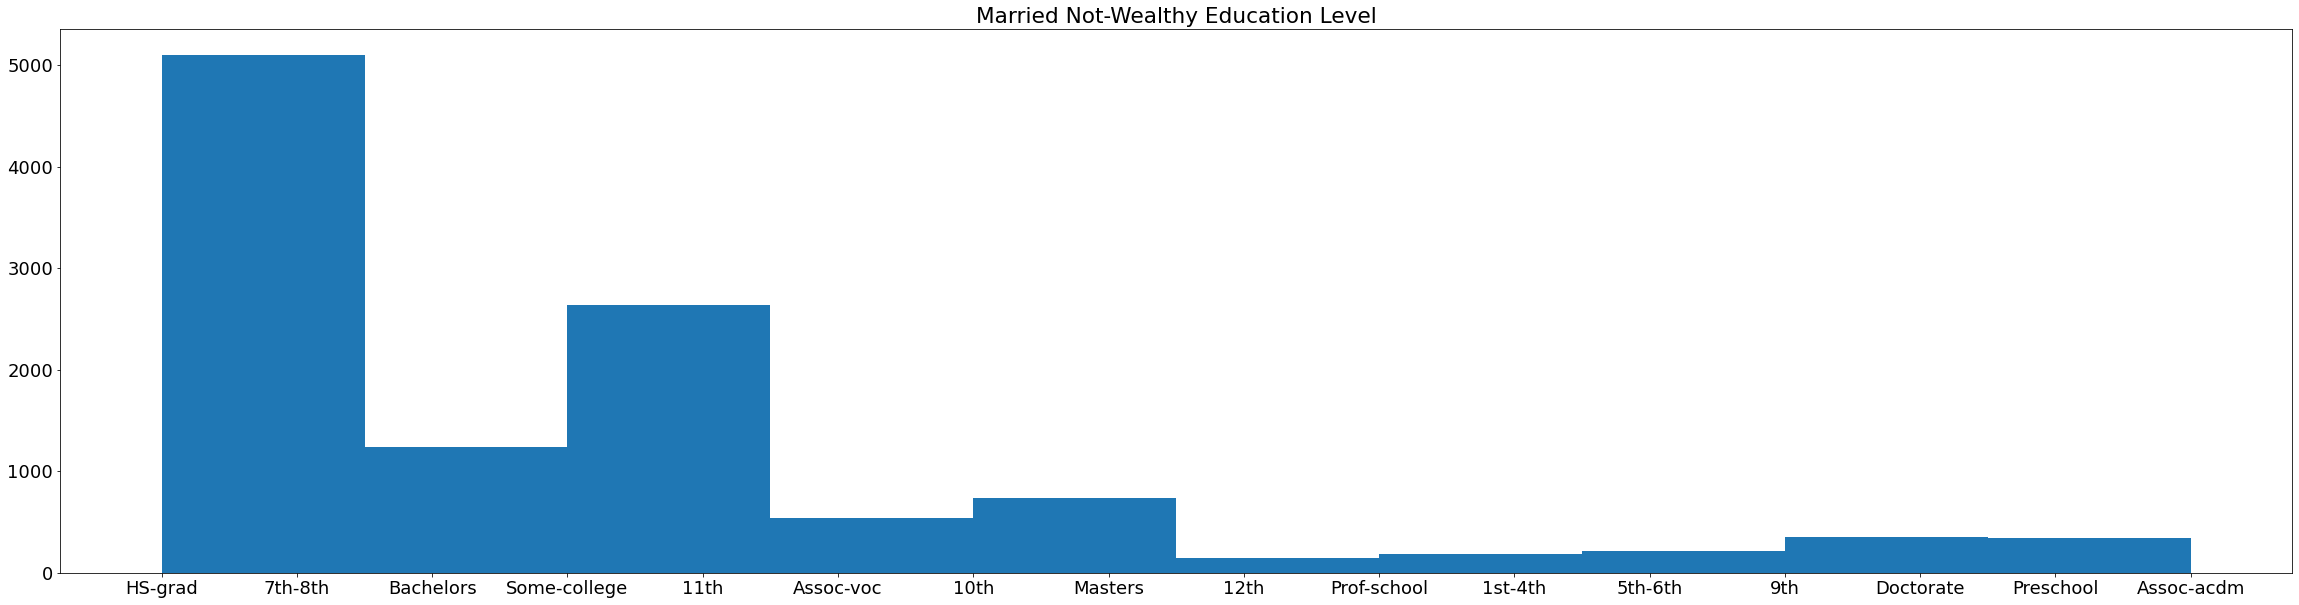

In [22]:
mr = he[he['marital-status']=='Married-civ-spouse']
plt.title('Married Wealthy Education Level')
plt.hist(mr['education'])
plt.show()

ml = le[le['marital-status']=='Married-civ-spouse']
plt.title('Married Not-Wealthy Education Level')
plt.hist(ml['education'])
plt.show()

The above clearly shows that those who are married and wealthy on average tend to have more education.

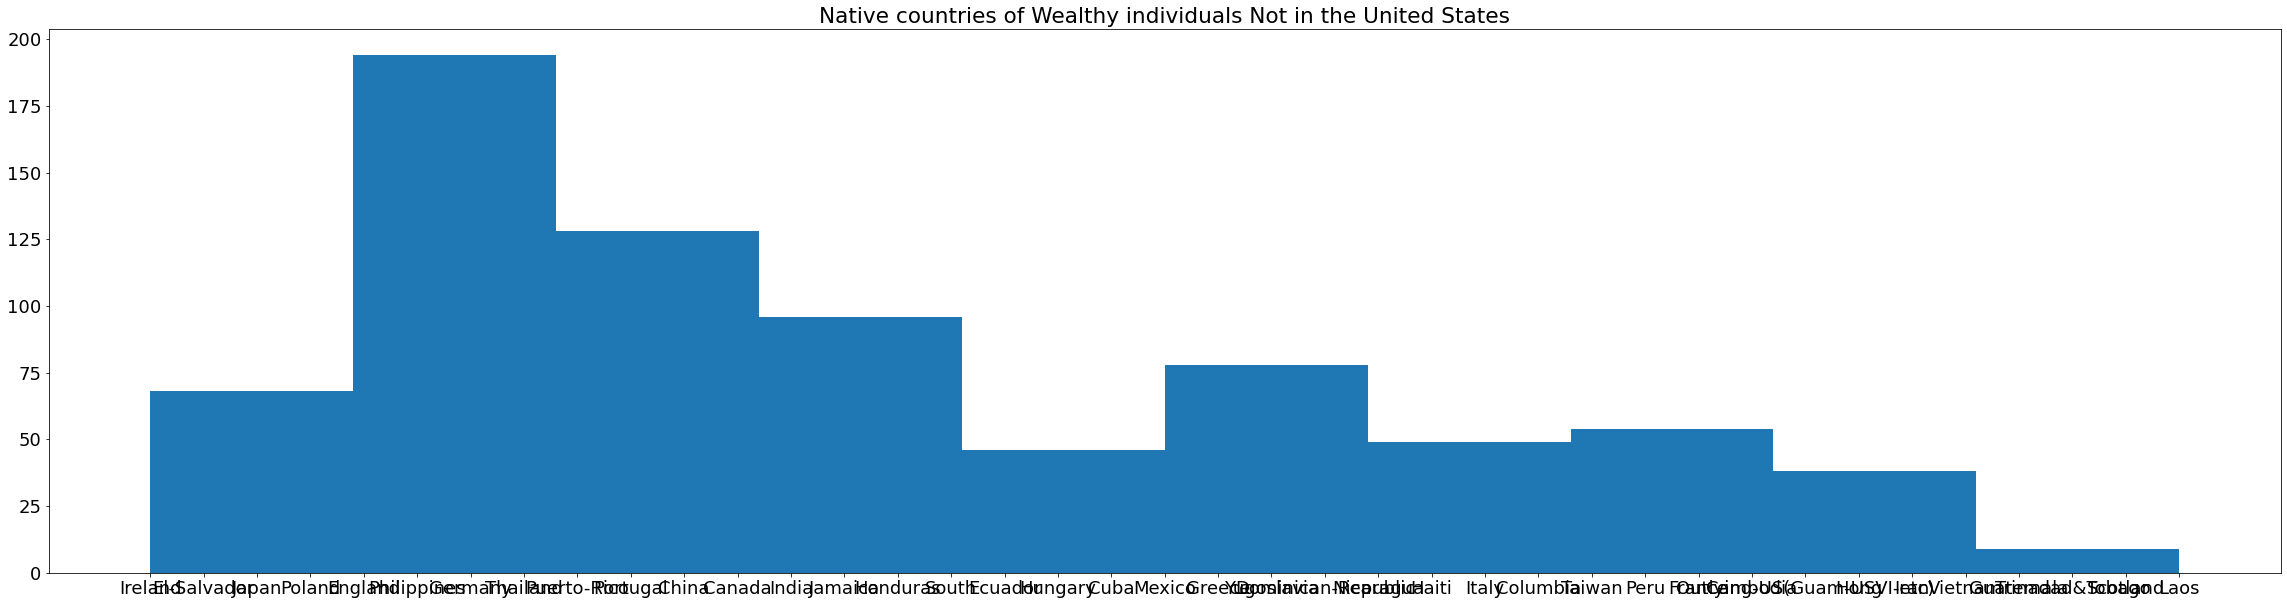

In [23]:
wi = he[he['native-country']!='United-States']
plt.title('Native countries of Wealthy individuals Not in the United States')
plt.hist(wi['native-country'])
plt.show()

A bit hard to see but it looks like Germany has the most high paid subjects outside the united states.
Lets see what their occupations are ?

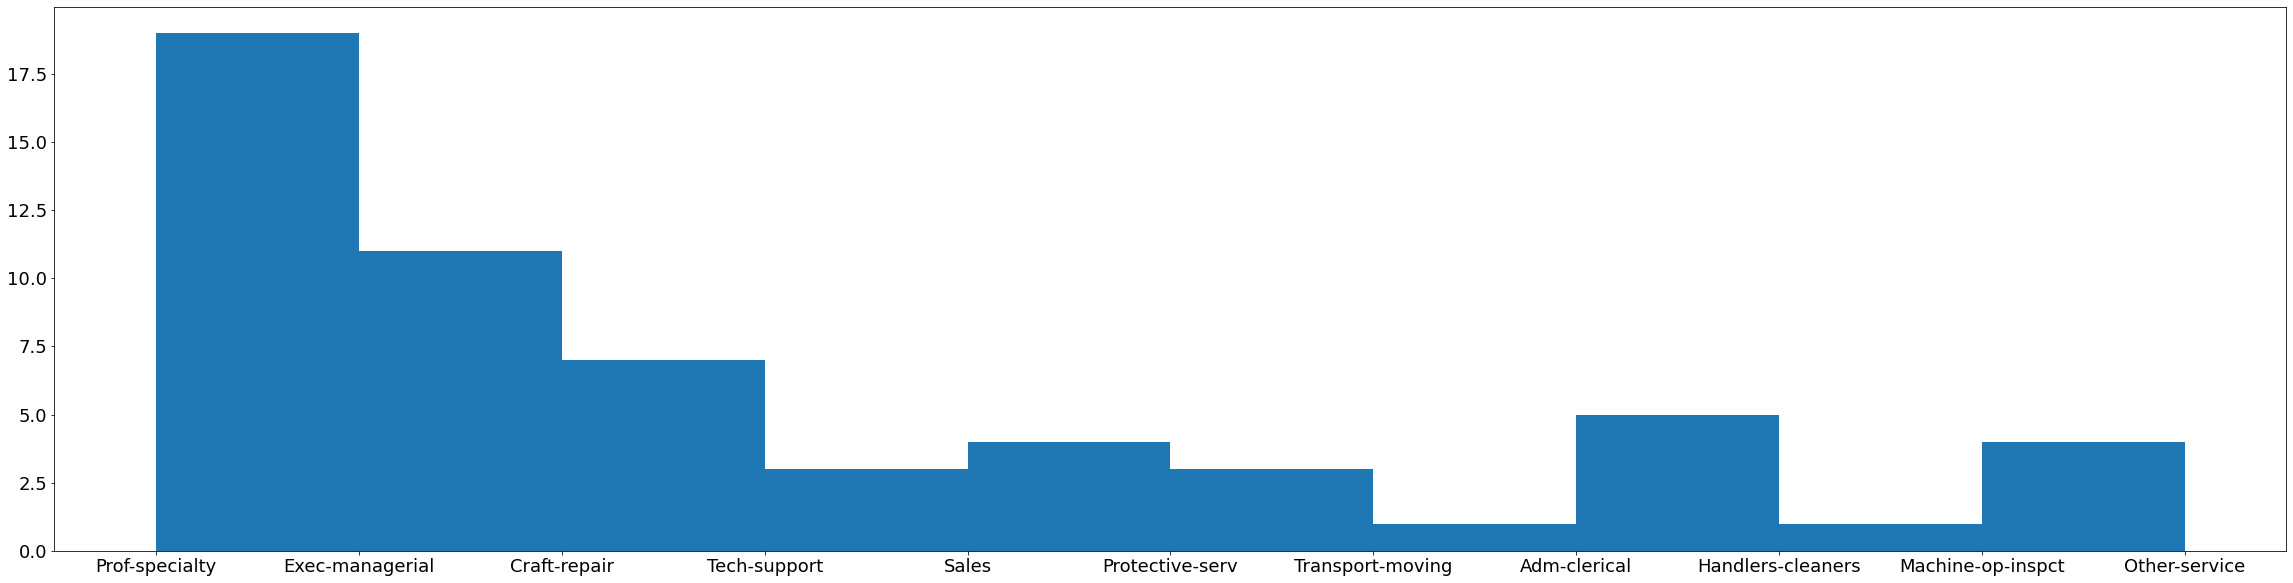

In [24]:
wger = wi[wi['native-country']=='Germany']
plt.hist(wger['occupation'])
plt.show()

Looks like most wealthy germans have a proffessional specialty

In [25]:
X = df.drop('income',axis=1)
y = df['income']
y

0        <=50K
1        <=50K
2         >50K
3         >50K
5        <=50K
         ...  
48837    <=50K
48838     >50K
48839    <=50K
48840    <=50K
48841     >50K
Name: income, Length: 45222, dtype: object

Can I discover waether someone is wealthy or not by the attributes they possess ?
Binary classification is a simple problem to solve when using the right tools.

One of the most difficult challenges is dealing with categorical variables. 
The problem is quite obvious when you think about it, we need to use nonnumeric variables in a function that can only take numeric values.
How can we do this ? THe answer is a simple trick called One Hot Encoding.

One hot encoding will generate several categories and the samples will have a value of 0 or 1 to indicate weather or not that sample is within the category.
SO for example if you chose gender as Male and Female 2 categories would be created. and Each subject would have a 1 in either column and a 0 in the other.

In this case we have multiple categorical variables some haveing more than one category so this adds many varibles to the dataset.
Once created we now have a dataframe that displays the same information but now can be read and understood by computer.

In [38]:
enc_df= pd.get_dummies(X)
enc_df.head()

,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week,workclass_Federal-gov,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,25,226802,7,0,0,40,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
1,38,89814,9,0,0,50,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
2,28,336951,12,0,0,40,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
3,44,160323,10,7688,0,40,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
5,34,198693,6,0,0,30,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0


Can we build a model that will predict weather someone is above or below the poverty line ?
First lets see how you preform o your own.

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Split the data into a training and test set.
X_train, X_test, y_train, y_test  = train_test_split(enc_df,y,random_state=5)

I would Like to examine my test set to see of we can guess the outcome of some random subjects.
CLick the below to get a new random subject, guess there income and get the result, how fun!

In [42]:
sample = X.sample()
s_list = list(sample.index)

print('The Randomly chosen subjects are: '+str(sample.index))
sample

The Randomly chosen subjects are: Int64Index([34708], dtype='int64')


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country
34708,41,Private,67065,Assoc-voc,11,Married-civ-spouse,Sales,Husband,White,Male,0,0,40,United-States


In [43]:
# Run the script to see the result !
df.loc[s_list]

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
34708,41,Private,67065,Assoc-voc,11,Married-civ-spouse,Sales,Husband,White,Male,0,0,40,United-States,<=50K


Now we introduce machine learning. We use Logistic Regression to capture the relationship between all the subjects attributes in the training sample and the target category.
Then a model is built to estimate the correct function to describe this complex relationship. This model can then be used to predict weather a subject makes more or less than 50K.

In [30]:
#First we split training and testing sets and use them to see how accurate our model is straight out of the box with no additional tuning.
X_train, X_test, y_train, y_test  = train_test_split(enc_df.values,y.values,random_state=5)

In [48]:
clf = LogisticRegression()
# Fit the model on the trainng data.
clf.fit(X_train, y_train)
# Print the accuracy from the testing data.
print('Results from initial Logistic Regression')
print(accuracy_score(clf.predict(X_test), y_test))

Results from initial Logistic Regression
0.7927649035910136


We can see the model is fairly accurate having no additional tuning and feature creation.
All we need was a single function pd.get_dummies to convert our dataframe of mixed types to an easily interpretible machine learning problem.

From there a simple scikit learn model out of the box allready gets us an accuracy of just under 80%

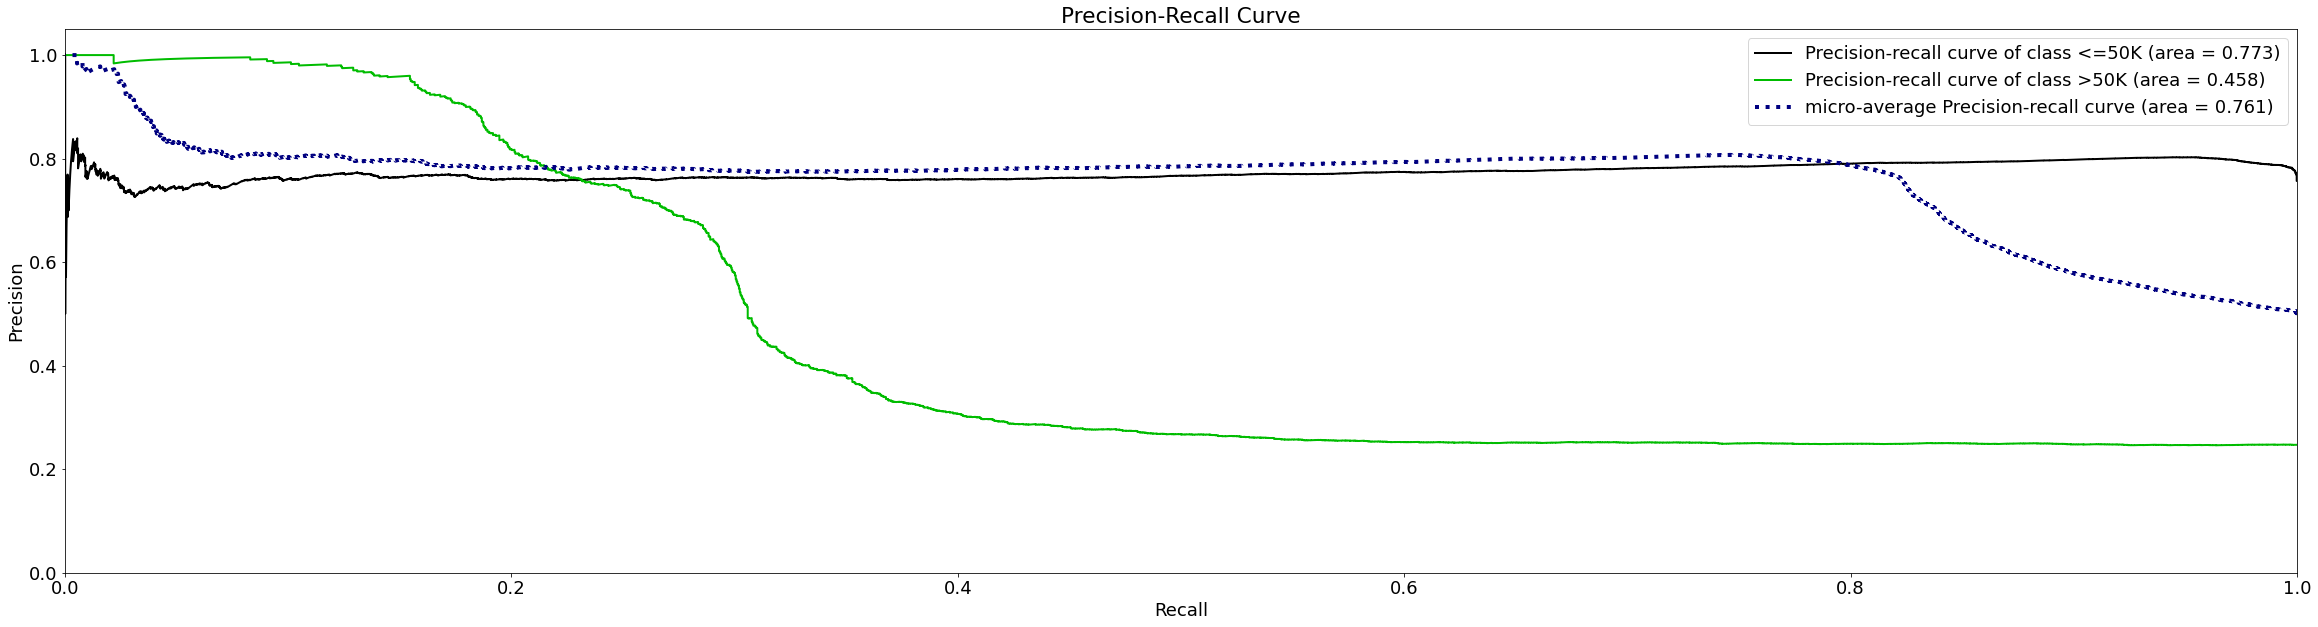

In [45]:
#Citation: https://www.kaggle.com/robjan/binary-classification-with-visualization
from sklearn.metrics import roc_auc_score
import scikitplot as skplt

y_pred_proba = clf.predict_proba(X_test)
skplt.metrics.plot_precision_recall(y_test, y_pred_proba)
plt.show()

In [47]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

clf = LogisticRegression()
rf = RandomForestClassifier()

print('Result from Logistic Regression')
print(cross_val_score(clf,enc_df,y,cv=5,scoring='roc_auc'))
print('Result from Random Forest Classifier')
print(cross_val_score(rf,enc_df,y,cv=5,scoring='roc_auc'))

Result from Logistic Regression
[0.57008341 0.57892445 0.57480121 0.56981882 0.58404636]
Result from Random Forest Classifier
[0.89874    0.89897147 0.89642681 0.90361023 0.90564524]


Citation#https://machinelearningmastery.com/roc-curves-and-precision-recall-curves-for-classification-in-python/##
by Jason Brownlee on August 31, 2018 in Probability(Citation needed)


'The Precision Recall Curve is especially useful in binary classification problems."
"Precision is a ratio of the number of true positives divided by the sum of the true positives and false positives. It describes how good a model is at predicting the positive class. Precision is referred to as the positive predictive value."